# GCC128 — Inteligência Artificial
## Trabalho Prático 03 — MLPClassifier

Classificação com rede neural **MLP** (Multi-Layer Perceptron), usando o `MLPClassifier` do
Scikit-learn, sobre as bases **Iris** e **Wine**.

Ao final, os resultados são comparados com o **KNN do Trabalho Prático 01**, executado sobre
exatamente as mesmas partições.

## 1. Importações e configuração

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score)

SEMENTE = 42        # reprodutibilidade
PROP_TESTE = 0.3    # 70% treino / 30% teste
K_KNN = 5           # melhor valor de k obtido no TP01

ROXO, VERDE, DOURADO = "#5B3E8E", "#7FA88C", "#D99A3E"

## 2. Bases de dados

O trabalho usa duas bases, conforme o enunciado:

- **Iris** — 150 amostras, 4 atributos, 3 espécies de flor
- **Wine** — 178 amostras, 13 atributos, 3 cultivares de vinho

A divisão é de 70% para treino e 30% para teste, **estratificada**, o que preserva a
proporção das classes nos dois conjuntos. A semente fica fixa em 42, de modo que o MLP e o
KNN recebem exatamente as mesmas partições — condição para que a comparação seja justa.

In [2]:
bases = {}
for nome, carga in [("Iris", load_iris), ("Wine", load_wine)]:
    b = carga()
    X, y = b.data, b.target
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=PROP_TESTE,
                                          stratify=y, random_state=SEMENTE)
    bases[nome] = dict(X=X, y=y, Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte,
                       classes=list(b.target_names), atributos=list(b.feature_names))
    print(f"{nome}: {X.shape[0]} amostras, {X.shape[1]} atributos, {len(b.target_names)} classes"
          f"  |  treino {len(Xtr)}, teste {len(Xte)}")

Iris: 150 amostras, 4 atributos, 3 classes  |  treino 105, teste 45
Wine: 178 amostras, 13 atributos, 3 classes  |  treino 124, teste 54


## 3. Padronização dos atributos

A MLP aprende por gradiente descendente. Quando os atributos estão em escalas muito
diferentes, os pesos ligados aos atributos de maior magnitude dominam o gradiente e o
treinamento fica instável. Por isso a padronização é prática recomendada para redes neurais.

Na **Wine** o problema é evidente: o atributo *proline* varia em mais de 1.400 unidades,
enquanto outros variam menos de 1. Na **Iris**, todos os atributos estão em centímetros e na
mesma ordem de grandeza.

A célula abaixo mede o efeito, repetindo o treino com 10 sementes diferentes.

In [3]:
for nome in bases:
    d = bases[nome]
    amp = d["X"].max(0) - d["X"].min(0)
    print(f"{nome} — amplitude dos atributos: min {amp.min():.2f}, max {amp.max():.2f}, "
          f"razao {amp.max()/amp.min():.0f}x")

print("\nAcuracia da MLP em 10 sementes (media +/- desvio padrao):")
for nome in bases:
    d = bases[nome]
    for rotulo, construtor in [
        ("sem padronizacao", lambda s: MLPClassifier(hidden_layer_sizes=(100,),
                                                     max_iter=2000, random_state=s)),
        ("com padronizacao", lambda s: make_pipeline(StandardScaler(),
                             MLPClassifier(hidden_layer_sizes=(100,),
                                           max_iter=2000, random_state=s)))]:
        accs = [accuracy_score(d["yte"], construtor(s).fit(d["Xtr"], d["ytr"]).predict(d["Xte"]))
                for s in range(10)]
        print(f"  {nome:>5} {rotulo}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}"
              f"   (min {min(accs):.4f}, max {max(accs):.4f})")

Iris — amplitude dos atributos: min 2.40, max 5.90, razao 2x
Wine — amplitude dos atributos: min 0.53, max 1402.00, razao 2645x

Acuracia da MLP em 10 sementes (media +/- desvio padrao):


   Iris sem padronizacao: 0.9778 +/- 0.0000   (min 0.9778, max 0.9778)


   Iris com padronizacao: 0.9178 +/- 0.0102   (min 0.9111, max 0.9333)


   Wine sem padronizacao: 0.7481 +/- 0.2552   (min 0.2778, max 0.9630)


   Wine com padronizacao: 0.9815 +/- 0.0117   (min 0.9630, max 1.0000)


O resultado confirma a necessidade. Na **Wine**, sem padronização a acurácia média cai e o
desvio padrão explode — em algumas sementes o modelo praticamente não aprende. Com
padronização, o comportamento fica estável.

Na **Iris**, a rede funciona bem nos dois casos, já que os atributos já estão em escala
comparável.

Adotamos a padronização nas duas bases, aplicada dentro de um `Pipeline`. Isso garante que a
média e o desvio padrão sejam calculados **apenas no conjunto de treino** e depois aplicados
ao teste, evitando vazamento de informação.

## 4. Treinamento do MLPClassifier

Arquitetura: uma camada oculta com 100 neurônios, ativação ReLU e otimizador Adam (padrões da
biblioteca). O `max_iter` foi elevado a 2000 para garantir a convergência.

In [4]:
def treinar_mlp(d):
    modelo = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=SEMENTE))
    modelo.fit(d["Xtr"], d["ytr"])
    return modelo


def treinar_knn(d):
    modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=K_KNN))
    modelo.fit(d["Xtr"], d["ytr"])
    return modelo


modelos = {}
for nome in bases:
    d = bases[nome]
    modelos[nome] = {"MLPClassifier": treinar_mlp(d), "KNN (k=5)": treinar_knn(d)}
    rede = modelos[nome]["MLPClassifier"].named_steps["mlpclassifier"]
    print(f"{nome}: convergiu em {rede.n_iter_} iteracoes | "
          f"camada oculta {rede.hidden_layer_sizes} | loss final {rede.loss_:.5f}")

Iris: convergiu em 523 iteracoes | camada oculta (100,) | loss final 0.04257
Wine: convergiu em 264 iteracoes | camada oculta (100,) | loss final 0.01224


## 5. Matriz de confusão e métricas de avaliação

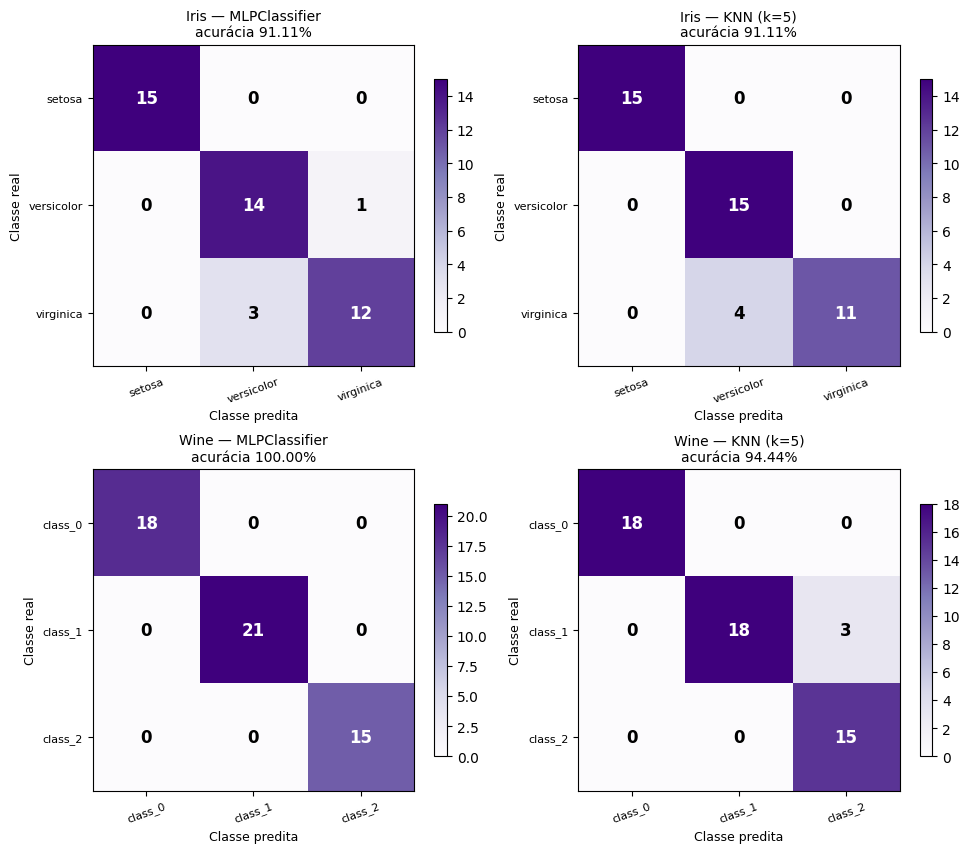

In [5]:
def avaliar(modelo, d):
    p = modelo.predict(d["Xte"])
    return dict(pred=p,
                mc=confusion_matrix(d["yte"], p),
                precisao=precision_score(d["yte"], p, average=None, zero_division=0),
                revocacao=recall_score(d["yte"], p, average=None, zero_division=0),
                acuracia=accuracy_score(d["yte"], p))


def plotar_matrizes(bases, modelos, avaliacoes):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8.6))
    for i, nome in enumerate(bases):
        for j, alg in enumerate(["MLPClassifier", "KNN (k=5)"]):
            ax = axes[i][j]
            mc = avaliacoes[nome][alg]["mc"]
            classes = bases[nome]["classes"]
            im = ax.imshow(mc, cmap="Purples")
            ax.set_xticks(range(len(classes)), classes, rotation=20, fontsize=8)
            ax.set_yticks(range(len(classes)), classes, fontsize=8)
            ax.set_xlabel("Classe predita", fontsize=9)
            ax.set_ylabel("Classe real", fontsize=9)
            acc = avaliacoes[nome][alg]["acuracia"]
            ax.set_title(f"{nome} — {alg}\nacurácia {acc*100:.2f}%", fontsize=10)
            limite = mc.max() / 2
            for a in range(len(classes)):
                for b_ in range(len(classes)):
                    ax.text(b_, a, mc[a, b_], ha="center", va="center", fontsize=12,
                            fontweight="bold",
                            color="white" if mc[a, b_] > limite else "black")
            fig.colorbar(im, ax=ax, shrink=0.75)
    fig.tight_layout()
    plt.show()


avaliacoes = {n: {a: avaliar(m, bases[n]) for a, m in modelos[n].items()} for n in bases}
plotar_matrizes(bases, modelos, avaliacoes)

In [6]:
for nome in bases:
    print(f"\n{'='*64}\n{nome}\n{'='*64}")
    for alg in ["MLPClassifier", "KNN (k=5)"]:
        r = avaliacoes[nome][alg]
        print(f"\n--- {alg} ---")
        print(f"{'classe':>20}{'precisao':>12}{'revocacao':>12}")
        for i, c in enumerate(bases[nome]["classes"]):
            print(f"{c:>20}{r['precisao'][i]:>12.4f}{r['revocacao'][i]:>12.4f}")
        print(f"{'MEDIA (macro)':>20}{r['precisao'].mean():>12.4f}{r['revocacao'].mean():>12.4f}")
        print(f"Acuracia: {r['acuracia']:.4f}  ({r['acuracia']*100:.2f}%)")


Iris

--- MLPClassifier ---
              classe    precisao   revocacao
              setosa      1.0000      1.0000
          versicolor      0.8235      0.9333
           virginica      0.9231      0.8000
       MEDIA (macro)      0.9155      0.9111
Acuracia: 0.9111  (91.11%)

--- KNN (k=5) ---
              classe    precisao   revocacao
              setosa      1.0000      1.0000
          versicolor      0.7895      1.0000
           virginica      1.0000      0.7333
       MEDIA (macro)      0.9298      0.9111
Acuracia: 0.9111  (91.11%)

Wine

--- MLPClassifier ---
              classe    precisao   revocacao
             class_0      1.0000      1.0000
             class_1      1.0000      1.0000
             class_2      1.0000      1.0000
       MEDIA (macro)      1.0000      1.0000
Acuracia: 1.0000  (100.00%)

--- KNN (k=5) ---
              classe    precisao   revocacao
             class_0      1.0000      1.0000
             class_1      1.0000      0.8571
            

## 6. Análise comparativa — MLPClassifier × KNN (TP01)

Os dois classificadores foram executados sobre as mesmas partições, com o mesmo
pré-processamento. O KNN usa k = 5, valor que apresentou a melhor taxa de reconhecimento no
Trabalho Prático 01.

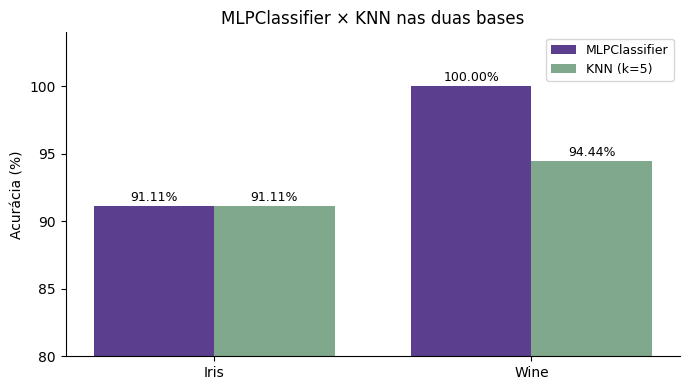

  base       algoritmo    acuracia    precisao   revocacao
  Iris   MLPClassifier      0.9111      0.9155      0.9111
  Iris       KNN (k=5)      0.9111      0.9298      0.9111
  Wine   MLPClassifier      1.0000      1.0000      1.0000
  Wine       KNN (k=5)      0.9444      0.9444      0.9524


In [7]:
def plotar_comparacao(bases, avaliacoes):
    algs = ["MLPClassifier", "KNN (k=5)"]
    x = np.arange(len(bases))
    largura = 0.38
    fig, ax = plt.subplots(figsize=(7, 4))
    for j, alg in enumerate(algs):
        vals = [avaliacoes[n][alg]["acuracia"] * 100 for n in bases]
        barras = ax.bar(x + (j - 0.5) * largura, vals, largura,
                        label=alg, color=[ROXO, VERDE][j])
        ax.bar_label(barras, fmt="%.2f%%", fontsize=9, padding=2)
    ax.set_xticks(x, list(bases.keys()))
    ax.set_ylim(80, 104)
    ax.set_ylabel("Acurácia (%)")
    ax.set_title("MLPClassifier × KNN nas duas bases")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


plotar_comparacao(bases, avaliacoes)

print(f"{'base':>6}{'algoritmo':>16}{'acuracia':>12}{'precisao':>12}{'revocacao':>12}")
for nome in bases:
    for alg in ["MLPClassifier", "KNN (k=5)"]:
        r = avaliacoes[nome][alg]
        print(f"{nome:>6}{alg:>16}{r['acuracia']:>12.4f}"
              f"{r['precisao'].mean():>12.4f}{r['revocacao'].mean():>12.4f}")

### Interpretação

**Na Iris os dois empatam em acurácia** (91,11%). É um resultado esperado: a base tem apenas
4 atributos e uma das classes é linearmente separável, de modo que a fronteira de decisão
necessária é simples. A capacidade extra da rede neural não encontra estrutura adicional para
aproveitar, e o KNN, que apenas compara distâncias, já resolve o problema. As duas abordagens
erram na mesma região — a fronteira entre *versicolor* e *virginica* —, o mesmo comportamento
observado no TP01.

**Na Wine o MLP se destaca**, com 100% contra 94,44% do KNN. Aqui a base tem 13 atributos, e a
classe é determinada por combinações entre eles, e não pela proximidade direta no espaço
original. O MLP aprende essas combinações nos pesos das camadas, enquanto o KNN depende de
que amostras da mesma classe estejam próximas — algo que se degrada conforme a dimensão
aumenta.

**Diferença de natureza.** O KNN é um método baseado em instâncias: não há treinamento, o
custo está todo na classificação, e o modelo é o próprio conjunto de dados. O MLP constrói um
modelo paramétrico no treino — 523 iterações na Iris e 264 na Wine — e depois classifica de
forma praticamente instantânea. O KNN não tem hiperparâmetros além de k e da métrica de
distância; o MLP tem arquitetura, função de ativação, otimizador e taxa de aprendizado, o que
o torna mais flexível e, ao mesmo tempo, mais trabalhoso de ajustar.

## 7. Conclusão

O `MLPClassifier` foi aplicado às bases Iris e Wine, com padronização dos atributos dentro de
um pipeline e partições estratificadas de 70/30. As matrizes de confusão e as métricas de
precisão, revocação e acurácia foram apresentadas para as duas bases.

Na comparação com o KNN do TP01, executado sobre as mesmas partições, os dois métodos
empataram na Iris (91,11%) e o MLP superou o KNN na Wine (100% contra 94,44%). O padrão
sugere que o ganho da rede neural aparece quando a base tem mais atributos e as classes
dependem de combinações entre eles; em problemas de baixa dimensão e fronteiras simples, um
método mais simples entrega o mesmo resultado com menos esforço de configuração.

O experimento de padronização reforçou um ponto prático: sem escalar os atributos, a MLP na
base Wine apresentou acurácia média de 74,81% com desvio padrão de 25,52% entre sementes,
chegando a 27,78% no pior caso. Com padronização, passou a 98,15% com desvio de 1,17%. Para
redes neurais, o pré-processamento não é detalhe de acabamento.